# LSTM for Time Series Data


![LSTM Gate Diagram](https://www.researchgate.net/publication/341131167/figure/fig1/AS:887489082445828@1588605294853/RNN-v-s-LSTM-a-RNNs-use-their-internal-state-memory-to-process-sequences-of-inputs_W640.jpg)


## LSTM Architecture

At the core of an LSTM cell are two main components: the cell state and the hidden state.
- **Cell State:** The cell state acts like a conveyor belt, running straight through the entire chain of LSTM cells. It's the main channel for information to flow without much alteration. It selectively carries information through the sequence, allowing the network to retain relevant information over long periods.
- **Hidden State:** The hidden state is the output of the LSTM cell at the current time step. It is a 'filtered' version of the cell state and the current input, and it is passed to the next LSTM cell and often used as the output for the current time step. It represents the short-term memory of the network.

LSTMs use a system of 'gates' to control the flow of information into and out of the cell state. These gates are essentially neural networks (typically using sigmoid and tanh activation functions) that selectively allow information to pass through. There are three main gates:

### Forget Gate
The forget gate decides what information to throw away from the cell state. It looks at the previous hidden state (h_t-1) and the current input (x_t), and outputs a number between 0 and 1 for each number in the cell state (C_t-1). A 1 means 'keep this completely', while a 0 means 'completely forget this'. This decision is made by a sigmoid function:
$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$
Where:
- $f_t$ is the forget gate vector.
- $\sigma$ is the sigmoid function.
- $W_f$ is the weight matrix for the forget gate.
- $[h_{t-1}, x_t]$ is the concatenation of the previous hidden state and the current input.
- $b_f$ is the bias vector for the forget gate.

### Input Gate
The input gate decides what new information to store in the cell state. It has two parts:
1. An input gate layer ($i_t$) which decides which values to update. This uses a sigmoid function:
$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$
2. A tanh layer ($\tilde{C}_t$) which creates a vector of new candidate values that could be added to the cell state:
$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$
The input gate then combines these two parts to update the cell state. It scales the candidate values by the input gate layer's output, deciding how much of each new value to add:
$C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t$
Where:
- $i_t$ is the input gate vector.
- $\tilde{C}_t$ is the candidate cell state vector.
- $W_i$ and $W_C$ are weight matrices.
- $b_i$ and $b_C$ are bias vectors.
- $C_t$ is the updated cell state.

### Output Gate
The output gate decides what the next hidden state ($h_t$) will be. It's based on the updated cell state ($C_t$) and the current input and previous hidden state. It has two parts:
1. An output gate layer ($o_t$) which uses a sigmoid function to decide which parts of the cell state to output:
$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$
2. The updated cell state is passed through a tanh function to scale the values between -1 and 1.
$\tanh(C_t)$
The output gate then multiplies these two parts to produce the next hidden state:
$h_t = o_t \cdot \tanh(C_t)$
Where:
- $o_t$ is the output gate vector.
- $h_t$ is the next hidden state.
- $W_o$ is the weight matrix.
- $b_o$ is the bias vector.

These gates work in concert to regulate the flow of information through the LSTM cell. By selectively adding, removing, and updating information in the cell state, LSTMs can effectively manage dependencies over long sequences, mitigating the vanishing gradient problem that plagues traditional RNNs. The cell state provides a direct path for information to travel, and the gates control the extent to which new information is added, old information is forgotten, and the current cell state influences the output and hidden state. This intricate mechanism allows LSTMs to learn and remember important information over extended periods, making them highly effective for a wide range of sequence modeling tasks.

![LSTM Gate Diagram](https://towardsdatascience.com/wp-content/uploads/2022/02/17cMfenu76BZCzdKWCfBABA.png)


## What is Time Series Data? 📈

A **time series** is a sequence of data points collected over a period of time. Unlike standard datasets where each data point can be treated independently, the defining feature of time series data is its **temporal ordering**-the order of the data points is critical.

Think of it as a story told through numbers. Shuffling the data points would be like shuffling the words in a sentence; you would lose the meaning.



### Key Characteristics:
* **Sequence Dependence:** The value at one point in time often depends on the values that came before it (this is also known as autocorrelation).
* **Trends & Seasonality:** The data often exhibits long-term trends (e.g., increasing sales over several years) and seasonal patterns (e.g., higher retail sales in December).

### Common Examples:
* **Finance:** Daily stock prices, currency exchange rates.
* **Meteorology:** Hourly temperature readings, monthly rainfall totals.
* **Business:** Weekly sales figures, daily website traffic.
* **Healthcare:** Heart rate monitoring data (EKG), patient admission rates.



In [33]:
# Import necessary libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [34]:
# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

# 'parse_dates' converts the 'Month' column to datetime objects.
# 'index_col' sets the 'Month' column as the index of the DataFrame.
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Check for any missing values in the entire DataFrame
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


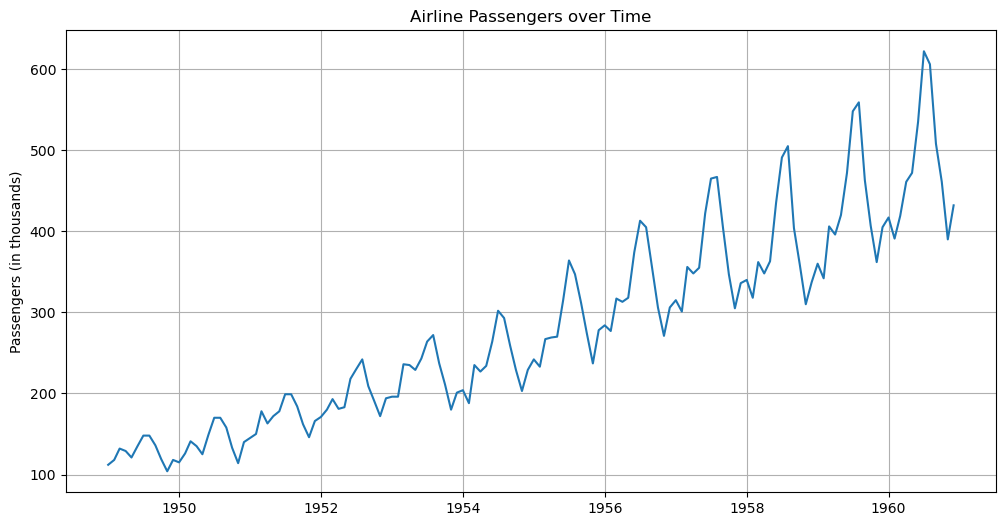

In [35]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.title('Airline Passengers over Time')
plt.ylabel('Passengers (in thousands)')
plt.grid(True)
plt.plot(df['Passengers'])
plt.show()

In [36]:
# Extract passenger numbers and scale them
# .values converts the 'Passengers' column to a NumPy array.
# .astype(np.float32) ensures the data is in 32-bit float format, which is common for neural networks.
# .reshape(-1, 1) changes the shape of the array to be a 2D array with one column, which is required by the scaler.
data = df['Passengers'].values.astype(np.float32).reshape(-1, 1)

# Initialize the MinMaxScaler to scale the data to a range of -1 to 1.
# This helps the neural network converge faster and perform better.
scaler = MinMaxScaler(feature_range=(-1, 1))
# Fit the scaler to the data (calculates the min and max values) and then transform the data to the scaled range.
data_normalized = scaler.fit_transform(data)

In [37]:
def create_sequences(data, seq_length):
    """
    Creates sequences and corresponding labels from time series data.
    For example, with a sequence length of 5, the input would be [t1, t2, t3, t4, t5] and the label would be [t6].
    """
    xs, ys = [], []  # Initialize lists to store the input sequences (xs) and labels (ys)
    # Iterate through the data to create overlapping windows
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]  # The input sequence is a window of 'seq_length'
        y = data[i+seq_length]    # The label is the single data point immediately following the sequence
        xs.append(x)
        ys.append(y)
    # Convert the lists of sequences and labels to NumPy arrays
    return np.array(xs), np.array(ys)

sequence_length = 12 # Use 12 months of data to predict the 13th
# Create the input sequences and corresponding labels from the normalized data
X, y = create_sequences(data_normalized, sequence_length)

# Print the shapes of the created arrays to verify
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")




Shape of X: (132, 12, 1)
Shape of y: (132, 1)


In [46]:
print(df.head)

<bound method NDFrame.head of             Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]>


In [38]:
# Split data into training and testing sets
train_size = int(len(X) * 0.8) # Use 80% of the data for training
X_train, X_test = X[:train_size], X[train_size:]  # Split the input sequences
y_train, y_test = y[:train_size], y[train_size:]  # Split the corresponding labels

# Convert the NumPy arrays to PyTorch tensors, which are the primary data structure in PyTorch
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

# Create a DataLoader for batching the data
batch_size = 16 # Process the data in batches of 16 sequences at a time
# TensorDataset wraps the input sequences and labels together
train_dataset = TensorDataset(X_train, y_train)
# DataLoader makes it easy to iterate over the dataset in batches, with shuffling for better training
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Create a DataLoader for the test set (shuffling is not needed for evaluation)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [39]:
# Define the LSTM model architecture by creating a class that inherits from nn.Module
class LSTMModel(nn.Module):
    # The constructor for the model
    def __init__(self, input_size=1, hidden_layer_size=100, num_layers=2, output_size=1):
        super().__init__()  # Initialize the parent class (nn.Module)
        self.hidden_layer_size = hidden_layer_size  # Store the size of the hidden layer

        # Define the LSTM layer.
        # 'input_size' is the number of features in the input (1 for our univariate time series).
        # 'hidden_layer_size' is the number of features in the hidden state.
        # 'num_layers' is the number of stacked LSTM layers.
        # 'batch_first=True' means the input and output tensors are provided as (batch, seq, feature).
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)

        # Define the fully connected linear layer that will map the LSTM's output to the final prediction.
        self.linear = nn.Linear(hidden_layer_size, output_size)

    # The forward pass defines how input data flows through the model to produce an output.
    def forward(self, input_seq):
        # The LSTM layer returns the output of all time steps and the final hidden/cell states. We only need the output.
        lstm_out, _ = self.lstm(input_seq)
        # We take the output from the very last time step (lstm_out[:, -1, :]) and pass it to the linear layer.
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

# Check if a CUDA-enabled GPU is available and set the device accordingly. Training on a GPU is much faster.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the model.
# We increase the number of layers and hidden size for more capacity.
# .to(device) moves the model's parameters and buffers to the specified device (GPU or CPU).
model = LSTMModel(num_layers=10, hidden_layer_size=100).to(device)
# Define the loss function. Mean Squared Error (MSE) is common for regression tasks.
loss_function = nn.MSELoss()
# Define the optimizer. Adam is a popular and effective optimization algorithm.
# It will update the model's parameters (weights and biases) during training.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Print the model's architecture
print(model)

Using device: cpu
LSTMModel(
  (lstm): LSTM(1, 100, num_layers=10, batch_first=True)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)


In [40]:
epochs = 200  # The number of times to iterate over the entire training dataset
train_losses = []  # List to store the training loss for each epoch
test_losses = []   # List to store the validation loss for each epoch

# The main training loop
for i in range(epochs):
    # --- Training Phase ---
    model.train()  # Set the model to training mode (enables features like dropout)
    # Iterate over the training data in batches
    for seq, labels in train_loader:
        # Move the batch of sequences and labels to the selected device (GPU/CPU)
        seq, labels = seq.to(device), labels.to(device)
        # Reset the gradients from the previous iteration to prevent accumulation
        optimizer.zero_grad()
        # Forward pass: get the model's predictions for the current batch
        y_pred = model(seq)
        # Calculate the loss between the predictions and the actual labels
        single_loss = loss_function(y_pred, labels)
        # Backward pass: compute the gradients of the loss with respect to the model's parameters
        single_loss.backward()
        # Update the model's parameters using the computed gradients
        optimizer.step()

    # Store the loss of the last batch of the current epoch
    train_losses.append(single_loss.item())

    # --- Validation Phase ---
    model.eval()  # Set the model to evaluation mode (disables features like dropout)
    # Disable gradient calculation to save memory and computations, as it's not needed for validation
    with torch.no_grad():
        test_loss = 0
        # Iterate over the test (validation) data
        for seq, labels in test_loader:
            seq, labels = seq.to(device), labels.to(device)
            # Get predictions on the test data
            y_pred_test = model(seq)
            # Accumulate the loss for the test set
            test_loss += loss_function(y_pred_test, labels).item()
        # Calculate the average test loss for the epoch
        test_loss /= len(test_loader)
        test_losses.append(test_loss)

    # Print the training and test loss every 25 epochs to monitor progress
    if (i+1) % 25 == 0:
        print(f'Epoch {i+1}/{epochs} | Train Loss: {single_loss.item():.6f} | Test Loss: {test_loss:.6f}')

Epoch 25/200 | Train Loss: 0.046762 | Test Loss: 0.116007
Epoch 50/200 | Train Loss: 0.007029 | Test Loss: 0.026967
Epoch 75/200 | Train Loss: 0.007112 | Test Loss: 0.035157
Epoch 100/200 | Train Loss: 0.007116 | Test Loss: 0.021471
Epoch 125/200 | Train Loss: 0.004136 | Test Loss: 0.023289
Epoch 150/200 | Train Loss: 0.012278 | Test Loss: 0.018177
Epoch 175/200 | Train Loss: 0.009831 | Test Loss: 0.016449
Epoch 200/200 | Train Loss: 0.004989 | Test Loss: 0.019062


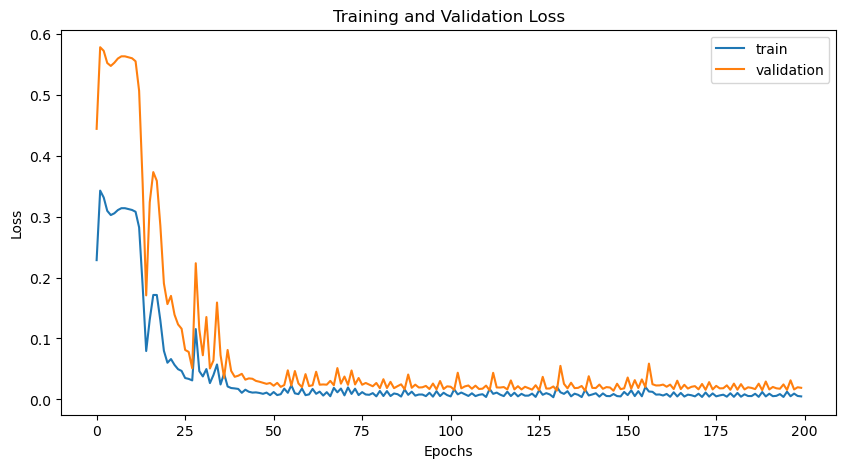

In [41]:
# Plotting the training and validation loss over epochs
plt.figure(figsize=(10, 5))
plt.title("Training and Validation Loss")
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [42]:
# Set the model to evaluation mode
model.eval()
all_preds = []  # List to store all predictions from the test set
# Disable gradient calculations for inference
with torch.no_grad():
    # Iterate over the test data loader
    for seq, labels in test_loader:
        # Move data to the same device as the model
        seq, labels = seq.to(device), labels.to(device)
        # Get model predictions
        preds = model(seq)
        # Move predictions to the CPU and convert to a NumPy array, then add to the list
        all_preds.extend(preds.cpu().numpy())

# Inverse transform the scaled predictions to get the actual passenger numbers
test_predictions = scaler.inverse_transform(np.array(all_preds))
# Inverse transform the scaled actual test labels to compare
y_test_actual = scaler.inverse_transform(y_test.numpy())

# Calculate the Root Mean Squared Error (RMSE) to evaluate the model's performance
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predictions))
print(f'Test RMSE: {rmse:.3f}')

Test RMSE: 34.377


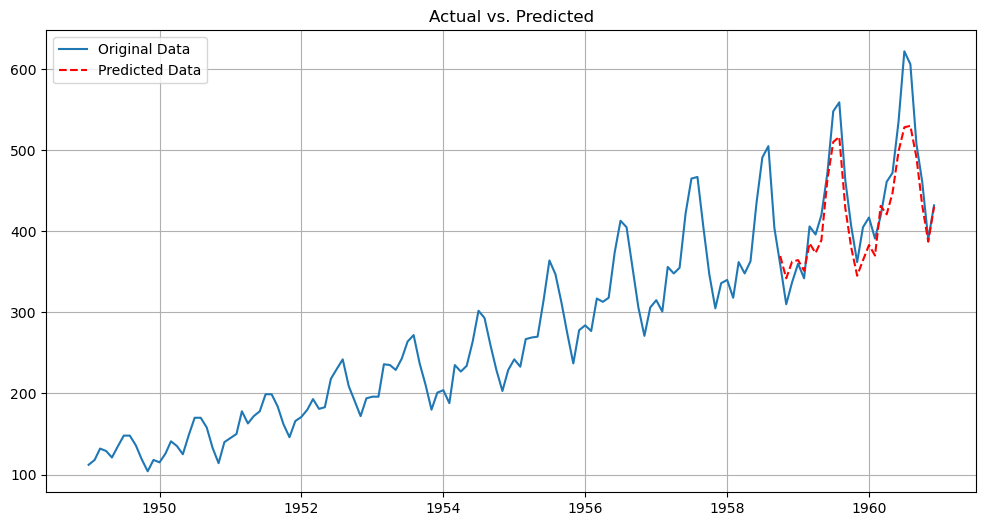

In [43]:
# Plotting the results to compare original data with predictions
# Get the correct date indices for the test predictions
test_indices = df.index[train_size+sequence_length:]

plt.figure(figsize=(12, 6))
plt.title('Actual vs. Predicted')
# Plot the entire original dataset
plt.plot(df.index, df['Passengers'], label='Original Data')
# Plot the predicted values for the test set period
plt.plot(test_indices, test_predictions, label='Predicted Data', color='red', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

/var/folders/30/t8p8dfxd5xz8dhykjhtqtrk80000gn/T/ipykernel_34889/496862064.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='M')[1:]


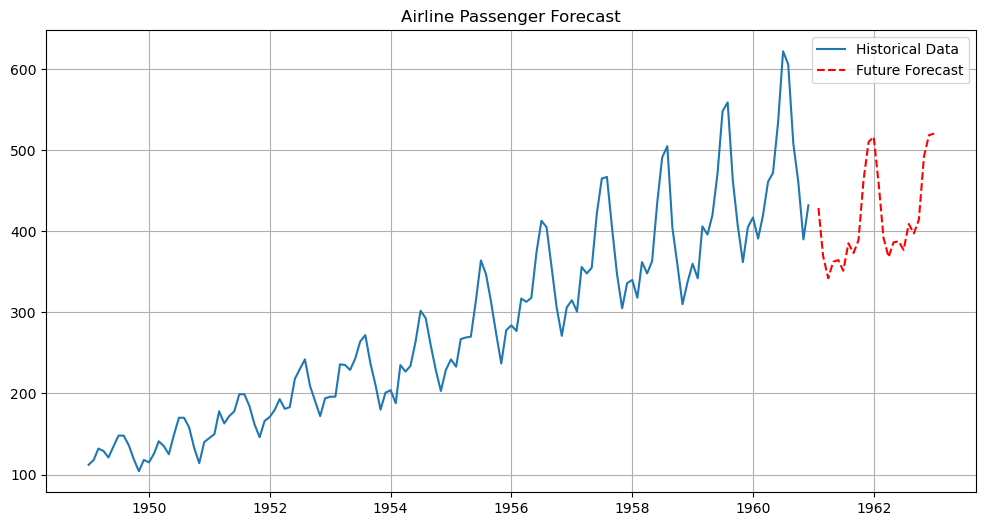

In [44]:
# Number of future periods to predict
future_steps = 24
# Get the last known sequence from the training data to start the forecast
last_seq = X_train[-1:].to(device)

future_predictions = []  # List to store the forecasted values
# Loop to generate future predictions one step at a time
for _ in range(future_steps):
    with torch.no_grad():
        # Get the prediction for the next step
        pred = model(last_seq)
        # Store the prediction
        future_predictions.append(pred.item())
        # Create a new sequence for the next prediction:
        # 1. Take the last part of the previous sequence (dropping the oldest value)
        new_seq = last_seq.cpu().numpy()[0][1:]
        # 2. Append the new prediction to the end
        new_seq = np.append(new_seq, pred.cpu().numpy()).reshape(1, sequence_length, 1)
        # 3. Convert back to a tensor and set it as the input for the next loop iteration
        last_seq = torch.from_numpy(new_seq).to(device).float()

# Inverse transform the scaled future predictions to the original passenger count scale
future_predictions_actual = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create the corresponding date indices for the future predictions
last_date = df.index[-1]  # Get the last date from the original data
# Generate a range of future dates with a monthly frequency ('M' is deprecated, 'ME' is month-end)
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='M')[1:]

# Plot the historical data along with the future forecast
plt.figure(figsize=(12, 6))
plt.title('Airline Passenger Forecast')
plt.plot(df.index, df['Passengers'], label='Historical Data')
plt.plot(future_dates, future_predictions_actual, label='Future Forecast', color='red', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

### How `nn.LSTM` Handles the Gates Internally

It's crucial to understand that `nn.LSTM` is a high-level abstraction. You don't create separate layers for each gate. Instead, PyTorch handles all the gate calculations internally in a highly optimized way.

Instead of performing four separate matrix multiplications for the three gates (forget, input, output) and the candidate cell state, PyTorch groups them into a single, large matrix multiplication. This is much faster on modern hardware like GPUs.

1.  **Combined Matrix Multiplication**: It uses one large weight matrix (`weight_ih`) for the input `x_t` and another (`weight_hh`) for the previous hidden state `h_{t-1}`.
2.  **Splitting the Result**: The result of this large operation is a single vector of size `4 * hidden_size`. This vector is then split into four chunks.
3.  **Applying Activations**: The appropriate activation function (Sigmoid or Tanh) is applied to each chunk, yielding the final values for the input gate, forget gate, output gate, and candidate state.

Let's inspect the parameters of an `nn.LSTM` layer to prove this.

In [45]:
# Define some parameters for a sample LSTM layer
input_size = 10
hidden_size = 20

# Create an LSTM layer instance
lstm_layer = nn.LSTM(input_size, hidden_size)

# Print the names and shapes of its learnable parameters
print(f"--- Parameters for an LSTM with input_size={input_size} and hidden_size={hidden_size} ---\n")
for name, param in lstm_layer.named_parameters():
    print(f"Parameter Name: {name}")
    print(f"Parameter Shape: {param.shape}\n")

print("Notice the shapes are 4 * hidden_size (4 * 20 = 80).")

--- Parameters for an LSTM with input_size=10 and hidden_size=20 ---

Parameter Name: weight_ih_l0
Parameter Shape: torch.Size([80, 10])

Parameter Name: weight_hh_l0
Parameter Shape: torch.Size([80, 20])

Parameter Name: bias_ih_l0
Parameter Shape: torch.Size([80])

Parameter Name: bias_hh_l0
Parameter Shape: torch.Size([80])

Notice the shapes are 4 * hidden_size (4 * 20 = 80).


## Next Steps: Try Advanced Concepts 
While LSTMs are effective, other architectures offer different advantages in performance and complexity.

1. Gated Recurrent Unit (GRU)
A GRU is a type of recurrent neural network similar to an LSTM but with a simpler design. It combines the forget and input gates into a single "update gate" and merges the cell state and hidden state.

    Why it's useful: With fewer parameters, GRUs are often faster to train than LSTMs and can perform just as well on many datasets. It's a great first alternative to try.

    Analogy: If an LSTM is a control panel with many knobs, a GRU is a more streamlined version with fewer, multi-function controls.

2. Bidirectional LSTMs/GRUs
A bidirectional RNN processes the sequence in two directions: forward (from start to end) and backward (from end to start). The outputs from both directions are then combined.

    Why it's useful: This allows the model to use both past and future context to make a prediction for a specific time step. It's extremely powerful for tasks like filling in missing values (imputation) or natural language processing.

    Important Note: For pure forecasting, where the future is unknown, bidirectional models are not directly applicable because they would require future data points to make a prediction.

